In [22]:
from transformers import pipeline

model = pipeline("sentiment-analysis")
print(model("I love this project"))

C:\Users\Felicia\AppData\Roaming\Python\Python311\site-packages\transformers\utils\generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


C:\Users\Felicia\AppData\Roaming\Python\Python311\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
No model was supplied, defaulted to distilbert-base-uncased-finetuned-sst-2-english and revision af0f99b (https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

C:\Users\Felicia\AppData\Roaming\Python\Python311\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Felicia\.cache\huggingface\hub\models--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to see activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

[{'label': 'POSITIVE', 'score': 0.999884843826294}]


In [24]:
print(model("This is terrible"))
print(model("I'm not sure how I feel about this"))

[{'label': 'NEGATIVE', 'score': 0.9996459484100342}]
[{'label': 'NEGATIVE', 'score': 0.9991093277931213}]


In [28]:
import requests

API_KEY = "b2a0d07341544104b699c5576a1bf7fd"

url = "https://newsapi.org/v2/everything"
params = {
    "q": "finance AND (stock market OR investment)",
    "language": "en",
    "apiKey": API_KEY
}

response = requests.get(url, params=params)
data = response.json()

articles = data["articles"]

news_list = []
for article in articles:
    text = article["title"] + " " + str(article["description"])
    news_list.append(text)

print(news_list[:3])

['Wall Street Is Already Betting on Prediction Markets As the legal war over how to regulate prediction markets rages on, financial institutions are embracing the industry anyway.', "An NYC couple went from 'autopilot' to financial independence. They share 3 money moves they made. Financial independence for Josette Chang and Alexander Nathanson came from strategic planning, smart investing, and eliminating mortgage debt.", 'The economy slowed in the last 3 months of the year -- but was still solid in 2025 The U.S. economy grew 2.2% in 2025, a modest slowdown from 2.4% the previous year.  GDP gains were fueled by solid consumer spending and business investment.', 'The private credit market has a growing AI problem AI-driven disruption, particularly in sectors like software, is increasingly being flagged as a risk.', 'Jim Cramer drops unexpected take on stock market Jim Cramer isn’t buying into the AI doomsday scenario. At a point when Mr. Market had gotten rattled by a viral memo from C

In [ ]:
# To get more articles

In [44]:
import requests
from datetime import datetime, timedelta

API_KEY = "b2a0d07341544104b699c5576a1bf7fd"
url = "https://newsapi.org/v2/everything"

# Query parameters
query = "finance AND (stock market OR investment)"
language = "en"
page_size = 100  # max per request

# Date range setup: last 30 days
end_date = datetime.today()
start_date = end_date - timedelta(days=30)

all_articles = []

# Split the 30-day range into 3-day chunks (adjust as needed)
delta = timedelta(days=3)
current_start = start_date

while current_start < end_date:
    current_end = min(current_start + delta, end_date)
    
    page = 1
    while True:
        params = {
            "q": query,
            "language": language,
            "pageSize": page_size,
            "page": page,
            "from": current_start.strftime("%Y-%m-%d"),
            "to": current_end.strftime("%Y-%m-%d"),
            "apiKey": API_KEY
        }

        response = requests.get(url, params=params)
        data = response.json()

        if "articles" in data and data["articles"]:
            all_articles.extend(data["articles"])
            if len(data["articles"]) < page_size:
                break  # No more pages for this date range
            page += 1
        else:
            break  # No articles for this page/date range

    current_start += delta

# Extract text
news_list = []
for article in all_articles:
    text = article.get("title", "") + " " + str(article.get("description", ""))
    news_list.append(text)

print(f"Total articles fetched: {len(news_list)}")
print(news_list[:10])

Total articles fetched: 883
["An NYC couple went from 'autopilot' to financial independence. They share 3 money moves they made. Financial independence for Josette Chang and Alexander Nathanson came from strategic planning, smart investing, and eliminating mortgage debt.", 'Jim Cramer drops unexpected take on stock market Jim Cramer isn’t buying into the AI doomsday scenario. At a point when Mr. Market had gotten rattled by a viral memo from Citrini Research’s Alap Shah...', "Homeowner Asked Neighbor To Move Fence After Survey Showed It Was 2 Feet Over — But He Refused, Claiming 'Squatter's Rights' Property lines are easy to ignore. Grass grows, fences fade into the background, and everyone assumes the boundary is where it's always been. Then someone...", "Tom Lee: Bitcoin's 50% Drop Is A 'Crypto Squall,' Not A Winter Fundstrat’s Tom Lee called Bitcoin’s (CRYPTO: BTC) 50% drawdown a “crypto squall” rather than a structural collapse, arguing technology and crypto sectors...", "Kalshi sa

In [52]:
results = []

for news in news_list:
    result = model(news[:512])[0]
    results.append(result)

print(results[:7])

[{'label': 'POSITIVE', 'score': 0.9984577894210815}, {'label': 'NEGATIVE', 'score': 0.995744526386261}, {'label': 'NEGATIVE', 'score': 0.9980201721191406}, {'label': 'NEGATIVE', 'score': 0.9952502250671387}, {'label': 'NEGATIVE', 'score': 0.9952002763748169}, {'label': 'POSITIVE', 'score': 0.9948099851608276}, {'label': 'POSITIVE', 'score': 0.9987713694572449}]


In [48]:
import pandas as pd

df = pd.DataFrame(results)
print(df.head())

      label     score
0  POSITIVE  0.998458
1  NEGATIVE  0.995745
2  NEGATIVE  0.998020
3  NEGATIVE  0.995250
4  NEGATIVE  0.995200


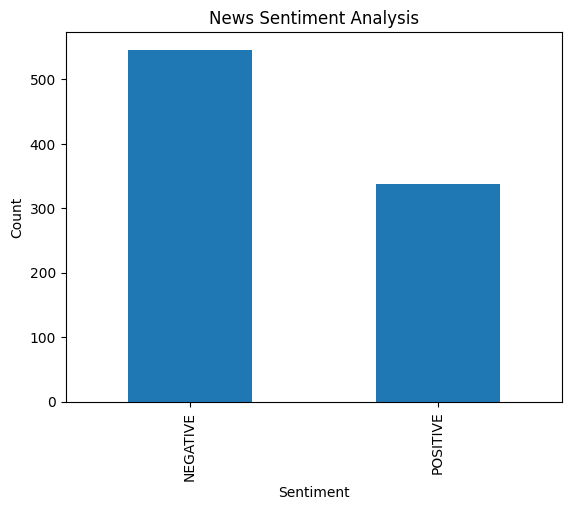

In [50]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.title("News Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()